In [2]:
import sys
sys.path.insert(0, "..")  

from tcr_pipeline.data_io import load_rdata, nested_dict_to_long, long_df_to_wide, save_noise_model, load_noise_model, parse_day
from tcr_pipeline.normalization import library_size_normalize, clr_normalize, tmm_normalize
from tcr_pipeline.visualization import show_traj, plot_noise_model, plot_trajectories
from tcr_pipeline.utils import summarize_nan_trajectories, impute_trajectories
from tcr_pipeline.nb_glm import fit_nb_dispersion_mle, _nb_neg_loglik

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Taking a look at the healthy data
Before anything, we will load and explore the healthy dataset. The original .rds data has already been converted into .csv tables with the load_rdata function. We offer two formats for the data: long (standard format of the .csv files) which will be used for the internal analysis funcions (such as fits, clustering, etc.) and wide (used for better reading and plotting).

In [3]:
healthy_df = pd.read_csv("../data/Healhy-Data-long.csv")

In [4]:
healthy_df

,patient,day,clono,count
0,HD106_SEQTR,0,clono_1,226089
1,HD106_SEQTR,0,clono_10,37237
2,HD106_SEQTR,0,clono_100,5035
3,HD106_SEQTR,0,clono_1000,830
4,HD106_SEQTR,0,clono_10000,247
...,...,...,...,...
2969987,HDBR06_SEQTR_ReSeq,105,clono_99934,34
2969988,HDBR06_SEQTR_ReSeq,105,clono_99946,53
2969989,HDBR06_SEQTR_ReSeq,105,clono_99969,206
2969990,HDBR06_SEQTR_ReSeq,105,clono_99982,22


In [5]:
wide_healthy_df = long_df_to_wide(healthy_df)

In [6]:
wide_healthy_df

{'HD106_SEQTR':                   0         46        82        131
 clono                                              
 clono_1      226089.0  238914.0  128798.0  150391.0
 clono_10      37237.0   33193.0   17378.0   19274.0
 clono_100      5035.0    5151.0    6618.0    5272.0
 clono_1000      830.0     826.0     418.0     822.0
 clono_10000     247.0       NaN       NaN       NaN
 ...               ...       ...       ...       ...
 clono_99995      52.0       NaN       NaN       NaN
 clono_99996      52.0       NaN       NaN       NaN
 clono_99997      52.0       NaN       NaN       NaN
 clono_99998      52.0       NaN       NaN       NaN
 clono_99999      52.0       NaN       NaN       NaN
 
 [678329 rows x 4 columns],
 'HD197_SEQTR':                   0         46        82        131
 clono                                              
 clono_1      102708.0  167519.0  164938.0  135860.0
 clono_10      32530.0   41806.0   38454.0   37936.0
 clono_100      4821.0    7905.0    805

### Number of NaNs/ 0's /MRI values
By looking at the table above, we can see that there are a number of NaN/MRI/0's values. To get a better idea of the shape of the healthy donor trajectories, we will count the number of NaNs in each trajectory. We can use the summatize_nan_function to get a per-donor/patients summary

In [7]:
nan_summary_healthy = summarize_nan_trajectories(healthy_df)

In [8]:
is_max = nan_summary_healthy.groupby("patient")["pct_clono"].transform("max") == nan_summary_healthy["pct_clono"]
nan_summary_healthy.style.apply(
    lambda col: ["background-color: lightgreen; font-weight: bold" if flag else "" for flag in is_max],
    subset=["pct_clono"]
)

,patient,n_timepoints,n_clonotypes,n_missing,n_clono,pct_clono
0,HD106_SEQTR,4,678329,0,10692,1.580000
1,HD106_SEQTR,4,678329,1,11997,1.770000
2,HD106_SEQTR,4,678329,2,33752,4.980000
3,HD106_SEQTR,4,678329,3,621888,91.680000
4,HD197_SEQTR,4,654981,0,15980,2.440000
5,HD197_SEQTR,4,654981,1,14007,2.140000
6,HD197_SEQTR,4,654981,2,35861,5.480000
7,HD197_SEQTR,4,654981,3,589133,89.950000
8,HDBR01_SEQTR_ReSeq,4,408644,0,4643,1.140000
9,HDBR01_SEQTR_ReSeq,4,408644,1,7515,1.840000


## Naïve NB fit
From the summary above, we can see that most of the clonotypes for all of the healthy donors have less than 2 timepoints. In the follwing section, we will fit a Negative Binomial model to charachterize neutral noise of the sampling+sequencing procedure. However, to fit the data of a clonotype we need >=2 timepoints, meaning we are discarding ~90% of the clontyopes per donor. 

Regardless, we will naïvely fit a NB model to the surviving data after filtering for clonotypes with >2 observations. In the remaining trajectories, dropouts/NaN will still exist. We will not impute them as 0 counts, as it migh zero-inflate the fit. 

In [9]:
healthy_ids = healthy_df['patient'].unique()
nb_models= {}
failed = []

for pid in healthy_ids:
    try:
        nb_models[pid] = fit_nb_dispersion_mle(healthy_df[healthy_df['patient'] == pid], min_obs=2)
    except ValueError as e:
        failed.append((pid, str(e)))

print(f"{len(nb_models)}/{len(healthy_ids)} donors fit successfully")
if failed:
    print("Failed:", failed)

6/6 donors fit successfully


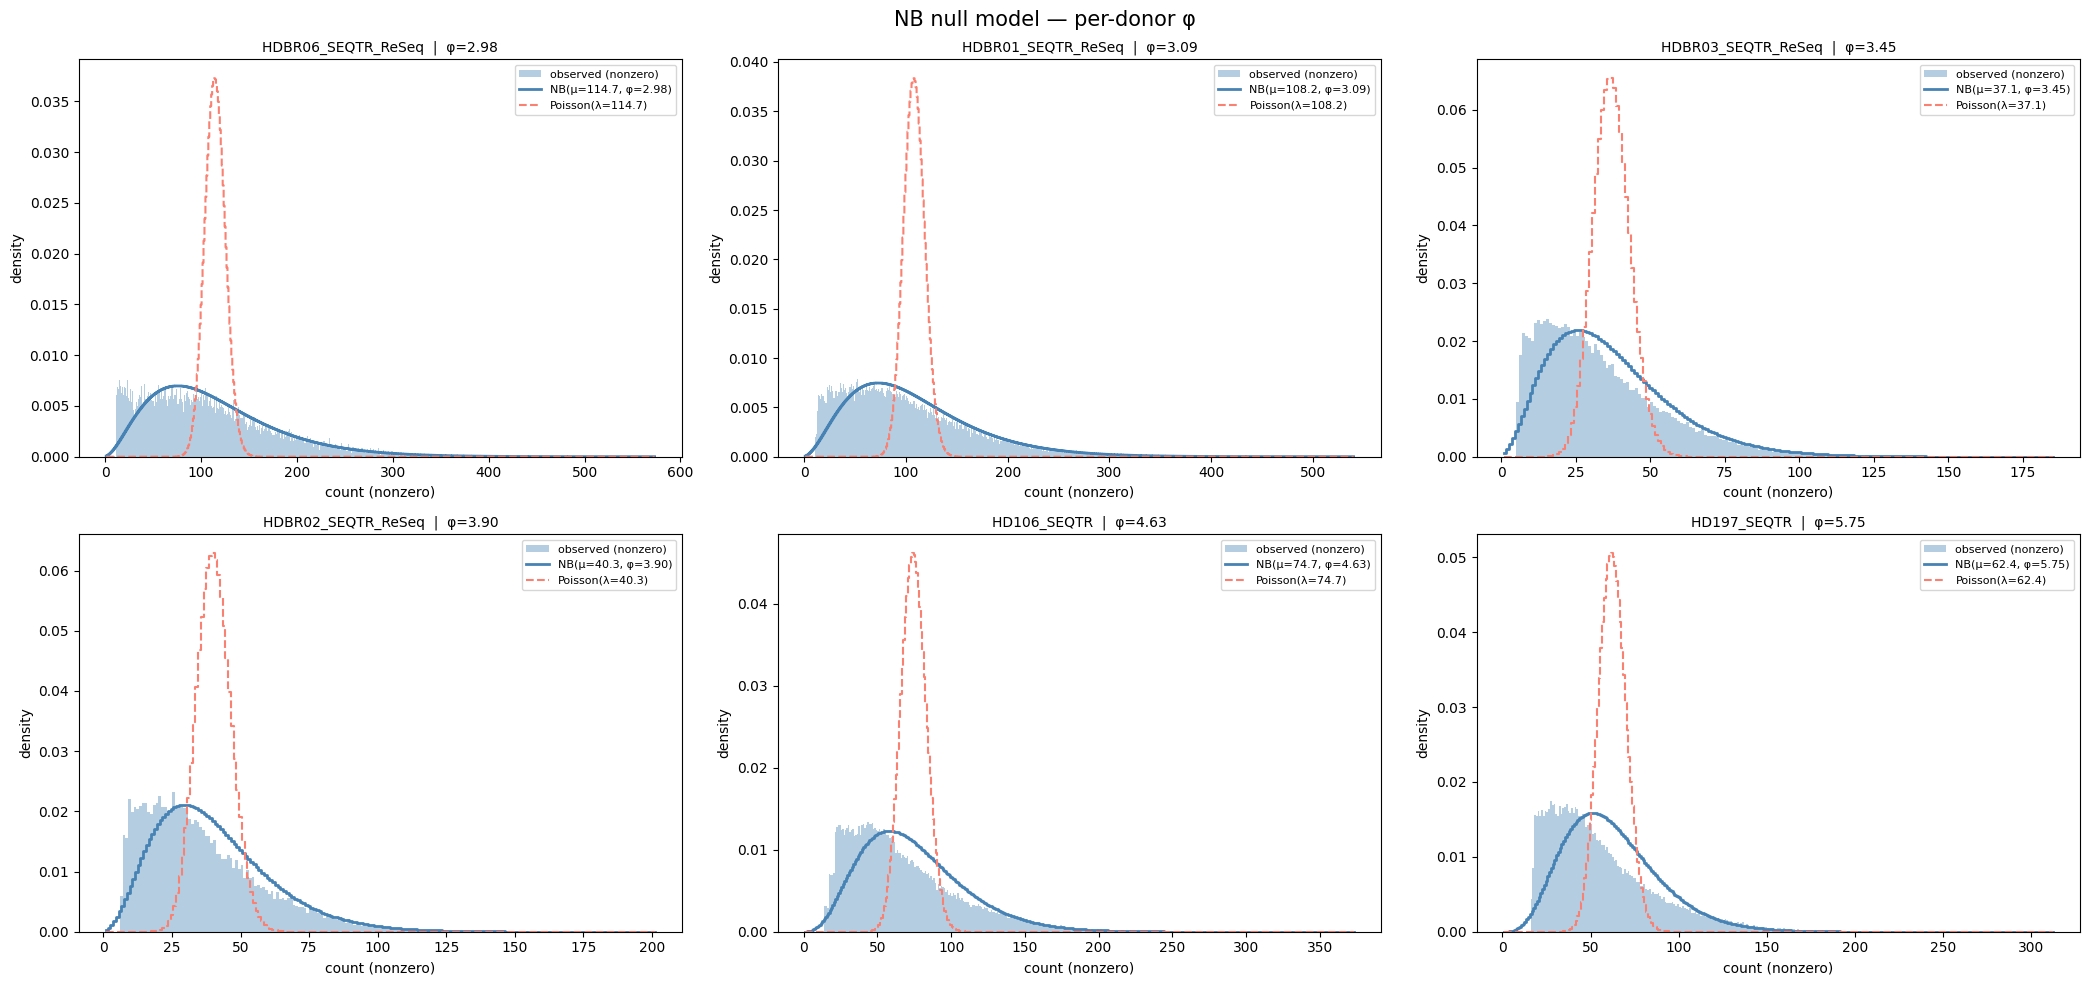

count    6.000
mean     3.968
std      1.060
min      2.980
25%      3.184
50%      3.677
75%      4.452
max      5.746
dtype: float64


In [10]:
from scipy.stats import nbinom, poisson
import math

phi_series = pd.Series({pid: v["phi"] for pid, v in nb_models.items()}).sort_values()
n_donors   = len(phi_series)

ncols = 3
nrows = math.ceil(n_donors / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
fig.suptitle("NB null model — per-donor φ", fontsize=15)
axes_flat = axes.flatten()

for i, pid in enumerate(phi_series.index):
    ax     = axes_flat[i]
    phi    = nb_models[pid]["phi"]
    x_all  = nb_models[pid]["x_all"]
    mu_all = nb_models[pid]["mu_all"]

    mu_rep = np.median(mu_all[mu_all > 0])
    x_plot = np.arange(1, int(mu_rep * 5) + 1)   # start at 1: exclude zeros

    mask     = (mu_all > mu_rep * 0.5) & (mu_all < mu_rep * 1.5)
    obs      = x_all[mask]
    obs_nonzero = obs[obs > 0]

    p      = phi / (phi + mu_rep)
    nb_pmf = nbinom.pmf(x_plot, n=phi, p=p)
    po_pmf = poisson.pmf(x_plot, mu_rep)

    # renormalise PMFs to sum to 1 over nonzero support so they're comparable
    nb_pmf_nz = nb_pmf / nb_pmf.sum()
    po_pmf_nz = po_pmf / po_pmf.sum()

    ax.hist(obs_nonzero, bins=x_plot, density=True, alpha=0.4,
            color="steelblue", label="observed (nonzero)")
    ax.step(x_plot, nb_pmf_nz / (x_plot[1] - x_plot[0]), color="steelblue",
            linewidth=2, label=f"NB(μ={mu_rep:.1f}, φ={phi:.2f})", where="mid")
    ax.step(x_plot, po_pmf_nz / (x_plot[1] - x_plot[0]), color="salmon",
            linewidth=1.5, linestyle="--",
            label=f"Poisson(λ={mu_rep:.1f})", where="mid")

    ax.set_title(f"{pid}  |  φ={phi:.2f}", fontsize=10)
    ax.set_xlabel("count (nonzero)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

# hide any unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("nb_fits_healthy.png")
plt.show()

print(phi_series.describe().round(3))

In the figure above, we compare the fit vs the count histogram and vs a poisson model, obtained in the limit when phi->infinity.
The NB fit provides a decent fit to the count data

In [11]:
phi_series = pd.Series({pid: v["phi"] for pid, v in nb_models.items()}).sort_values()
print(phi_series.to_string())
print(f"\nmean:   {phi_series.mean():.3f}")
print(f"median: {phi_series.median():.3f}")
print(f"std:    {phi_series.std():.3f}")

HDBR06_SEQTR_ReSeq    2.979542
HDBR01_SEQTR_ReSeq    3.094937
HDBR03_SEQTR_ReSeq    3.451390
HDBR02_SEQTR_ReSeq    3.902565
HD106_SEQTR           4.634584
HD197_SEQTR           5.745731

mean:   3.968
median: 3.677
std:    1.060


For the sake of this example, we will consider the per-donor dispersion values to be similar enough so that it is justified to pool them together, and fit one single NB to all the donor data. In reality, it might not be as justified.

In [12]:
nb_model_joint = fit_nb_dispersion_mle(healthy_df, min_obs=2)

In [13]:
nb_model_joint

{'phi': 4.011474656421975,
 'x_all': array([2.26089e+05, 2.38914e+05, 1.28798e+05, ..., 2.20000e+01,
        1.20000e+01, 3.40000e+01]),
 'mu_all': array([2.19393690e+05, 2.16510949e+05, 1.37207356e+05, ...,
        1.63965418e+01, 2.38164434e+01, 2.21835566e+01])}

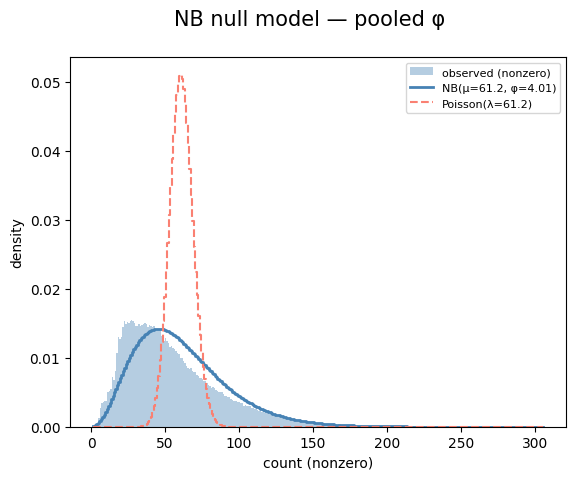

In [14]:
plt.suptitle("NB null model — pooled φ", fontsize=15)
phi    = nb_model_joint["phi"]
x  = nb_model_joint["x_all"]
mu = nb_model_joint["mu_all"]

mu_rep = np.median(mu)
x_plot = np.arange(1, int(mu_rep * 5) + 1)   # start at 1: exclude zeros

mask     = (mu > mu_rep * 0.5) & (mu < mu_rep * 1.5)
obs      = x[mask]
obs_nonzero = obs[obs > 0]

p      = phi / (phi + mu_rep)
nb_pmf = nbinom.pmf(x_plot, n=phi, p=p)
po_pmf = poisson.pmf(x_plot, mu_rep)

# renormalise PMFs to sum to 1 over nonzero support so they're comparable
nb_pmf_nz = nb_pmf / nb_pmf.sum()
po_pmf_nz = po_pmf / po_pmf.sum()

plt.hist(obs_nonzero, bins=x_plot, density=True, alpha=0.4,
        color="steelblue", label="observed (nonzero)")
plt.step(x_plot, nb_pmf_nz / (x_plot[1] - x_plot[0]), color="steelblue",
        linewidth=2, label=f"NB(μ={mu_rep:.1f}, φ={phi:.2f})", where="mid")
plt.step(x_plot, po_pmf_nz / (x_plot[1] - x_plot[0]), color="salmon",
        linewidth=1.5, linestyle="--",
        label=f"Poisson(λ={mu_rep:.1f})", where="mid")
plt.xlabel("count (nonzero)")
plt.ylabel("density")
plt.legend(fontsize=8)
plt.savefig("nb_pooled.png")

### Patient data: loading and examination
The next step would be to use the null model to determine which trajectories are non-neutral in patients. We start by loading the patient data

In [15]:
patient_df = pd.read_csv("../data/BRIOME_patients.csv")

In [16]:
patient_df

,patient,day,clono,count
0,BR032,0,clono_1,15814
1,BR032,0,clono_10,1442
2,BR032,0,clono_100,413
3,BR032,0,clono_1000,154
4,BR032,0,clono_10000,57
...,...,...,...,...
3193741,BR054,327,clono_9974,67
3193742,BR054,327,clono_99791,26
3193743,BR054,327,clono_99841,524
3193744,BR054,327,clono_9988,411


In [17]:
wide_patient_df = long_df_to_wide(patient_df)
wide_patient_df

{'BR032':                  0     26    47   110  187  425
 clono                                          
 clono_1      15814.0   NaN   NaN  NaN  NaN  NaN
 clono_10      1442.0  59.0  17.0  NaN  NaN  NaN
 clono_100      413.0   NaN   NaN  NaN  NaN  NaN
 clono_1000     154.0   NaN   NaN  NaN  NaN  NaN
 clono_10000     57.0   NaN   NaN  NaN  NaN  NaN
 ...              ...   ...   ...  ...  ...  ...
 clono_99995      8.0   NaN   NaN  NaN  NaN  NaN
 clono_99996      8.0   NaN   NaN  NaN  NaN  NaN
 clono_99997      8.0   NaN   NaN  NaN  NaN  NaN
 clono_99998      8.0   NaN   NaN  NaN  NaN  NaN
 clono_99999      8.0   NaN   NaN  NaN  NaN  NaN
 
 [696664 rows x 6 columns],
 'BR037':                  0     28       119     189     218     364
 clono                                                      
 clono_1      25132.0   NaN  17073.0  3654.0  3571.0  1307.0
 clono_10      2423.0   NaN   1273.0  3447.0  3068.0  1933.0
 clono_100      919.0   NaN    250.0   875.0   493.0   424.0
 clono_100

In [18]:
nan_summary_patient = summarize_nan_trajectories(patient_df)
is_max = nan_summary_patient.groupby("patient")["pct_clono"].transform("max") == nan_summary_patient["pct_clono"]
nan_summary_patient.style.apply(
    lambda col: ["background-color: lightgreen; font-weight: bold" if flag else "" for flag in is_max],
    subset=["pct_clono"]
)

,patient,n_timepoints,n_clonotypes,n_missing,n_clono,pct_clono
0,BR032,6,696664,0,60,0.010000
1,BR032,6,696664,1,2744,0.390000
2,BR032,6,696664,2,3986,0.570000
3,BR032,6,696664,3,8022,1.150000
4,BR032,6,696664,4,29332,4.210000
5,BR032,6,696664,5,652520,93.660000
6,BR037,6,453221,0,16,0.000000
7,BR037,6,453221,1,580,0.130000
8,BR037,6,453221,2,1034,0.230000
9,BR037,6,453221,3,2655,0.590000


### Identifying non-neutral trajectories
Again, we observe that most clonotypes have most of their timepoints missing. In the case of the patients, this should be adressed carefully. Because this is a naïve test to exeplify how the pipeline works, we will continue with the NB test.

In [19]:
phi_pooled = nb_model_joint["phi"]

In [20]:
from tcr_pipeline.nb_glm import nb_glm_trajectory_test, add_library_sizes, bh_correct

#Lets perform the test on two patients
test_pids = ["BR054", "BR037"]
patient_df_sub = patient_df[patient_df['patient'].isin(test_pids)].copy()

#Add library sizes to df 
patient_df_sub = add_library_sizes(patient_df_sub)

#Fir trajectory and perform likelihood ratio test
results = nb_glm_trajectory_test(patient_df_sub, dispersion=phi_pooled, min_obs=3)

#BH adjust for false positives
results['q_value'] = results.groupby('patient')['p_value'].transform(bh_correct)

In [21]:
results

,patient,clono,beta,se_beta,stat,p_value,n_obs,phi_used,direction,converged,q_value
0,BR037,clono_1,-0.010700,0.001869,24.730039,6.594826e-07,5,4.011475,contraction,True,0.000217
1,BR037,clono_10,-0.001376,0.001869,0.443868,5.052615e-01,5,4.011475,contraction,True,0.798361
2,BR037,clono_100,-0.003066,0.001874,2.615226,1.058424e-01,5,4.011475,contraction,True,0.370233
3,BR037,clono_1002,-0.010826,0.001953,19.418304,1.049959e-05,4,4.011475,contraction,True,0.001316
4,BR037,clono_10024,-0.002035,0.001962,1.036067,3.087378e-01,3,4.011475,contraction,True,0.647567
...,...,...,...,...,...,...,...,...,...,...,...
25396,BR054,clono_999,0.004044,0.001835,5.475503,1.928481e-02,5,4.011475,expansion,True,0.103829
25397,BR054,clono_9990,-0.001298,0.003607,0.139595,7.086842e-01,3,4.011475,contraction,True,0.876276
25398,BR054,clono_99903,-0.006684,0.004179,2.783277,9.525307e-02,3,4.011475,contraction,True,0.298201
25399,BR054,clono_9995,-0.003456,0.003911,0.838592,3.597998e-01,3,4.011475,contraction,True,0.641700


In [22]:
print("Test summary")
for pid in test_pids:
    sub = results[results['patient'] == pid]
    sig = sub[sub['q_value'] < 0.05]

    print(f"\nPatient: {pid}")
    print(f"  Total clonotypes tested:    {len(sub)}")
    print(f"  Converged:                  {sub['converged'].sum()} ({100*sub['converged'].mean():.1f}%)")
    print(f"  Significant (FDR 5%):       {len(sig)}")
    print(f"  Significant (FDR 10%):      {(sub['q_value'] < 0.10).sum()}")
    print(f"  Expansions  (FDR 5%):       {(sig['direction'] == 'expansion').sum()}")
    print(f"  Contractions (FDR 5%):      {(sig['direction'] == 'contraction').sum()}")
    print(f"\n  p-value distribution:")
    print(f"    < 0.001 : {(sub['p_value'] < 0.001).sum()}")
    print(f"    < 0.01  : {(sub['p_value'] < 0.01).sum()}")
    print(f"    < 0.05  : {(sub['p_value'] < 0.05).sum()}")
    print(f"\n  Top 5 expansions:")
    top_exp = sig[sig['direction'] == 'expansion'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_exp.to_string(index=False))
    print(f"\n  Top 5 contractions:")
    top_con = sig[sig['direction'] == 'contraction'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_con.to_string(index=False))
    print("-" * 60)

Test summary

Patient: BR054
  Total clonotypes tested:    21116
  Converged:                  21116 (100.0%)
  Significant (FDR 5%):       2936
  Significant (FDR 10%):      3854
  Expansions  (FDR 5%):       2543
  Contractions (FDR 5%):      393

  p-value distribution:
    < 0.001 : 1795
    < 0.01  : 3240
    < 0.05  : 5379

  Top 5 expansions:
      clono     beta      p_value      q_value  n_obs
clono_14649 0.028746 3.815289e-22 8.056365e-18      5
 clono_6043 0.025150 3.500776e-19 3.696119e-15      5
clono_74308 0.014313 1.158646e-14 8.155323e-11      5
clono_89033 0.014238 2.463686e-14 1.300580e-10      5
clono_68864 0.013886 8.984806e-14 3.794463e-10      4

  Top 5 contractions:
      clono      beta      p_value      q_value  n_obs
   clono_22 -0.083959 4.628157e-11 3.369937e-08      3
clono_99213 -0.026236 3.022176e-08 4.462676e-06      3
clono_99254 -0.026671 3.616648e-08 5.160077e-06      3
 clono_2821 -0.012482 4.367234e-08 5.873791e-06      5
clono_21476 -0.012043 1.50

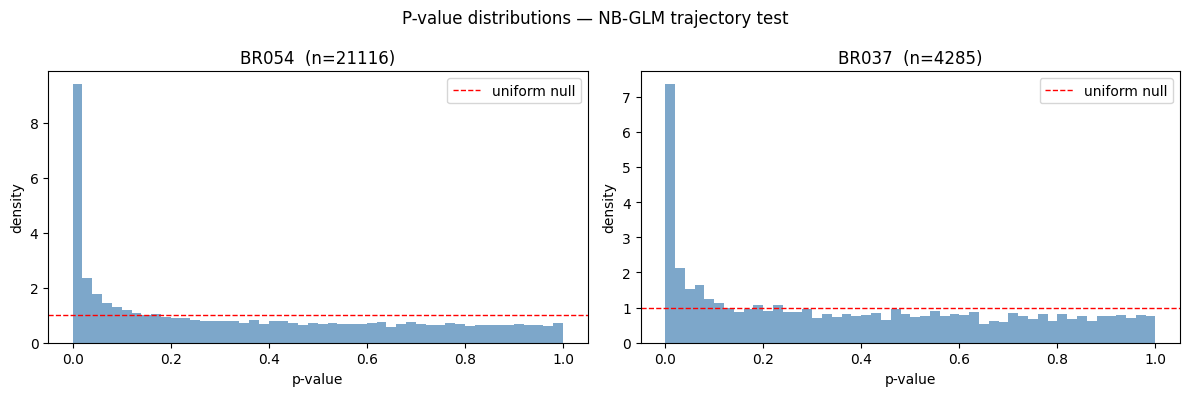

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("P-value distributions — NB-GLM trajectory test")

for ax, pid in zip(axes, test_pids):
    sub = results[results['patient'] == pid]
    ax.hist(sub['p_value'].dropna(), bins=50, density=True, color='steelblue', alpha=0.7)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='uniform null')
    ax.set_xlabel('p-value')
    ax.set_ylabel('density')
    ax.set_title(f"{pid}  (n={len(sub)})")
    ax.legend()

plt.tight_layout()
plt.savefig("p_value_test.png")
plt.show()

We have identified a set of non-neutral trajectories for both tested patients. A few thing to take into consideration, the hit rate seem to be high: ~13% and ~7% of tested clonotypes are flagged as non-neutral. This can be genuine change or a sign that the noise estimate is too loose. Also, we have to take into account that we have discarded upvards of 90% of clonotypes for each patients due to not having enough counts. Genuine contracting/expanding clonotypes might be present in this discarded batch. 


### Clustering
The next step is clustering trajectories (per patient) to determine similarities

BR054: 2936 clonotypes with >=3 timepoints for clustering
  Best k=5 (silhouette=0.749)
BR037: 308 clonotypes with >=3 timepoints for clustering
  Best k=6 (silhouette=0.627)


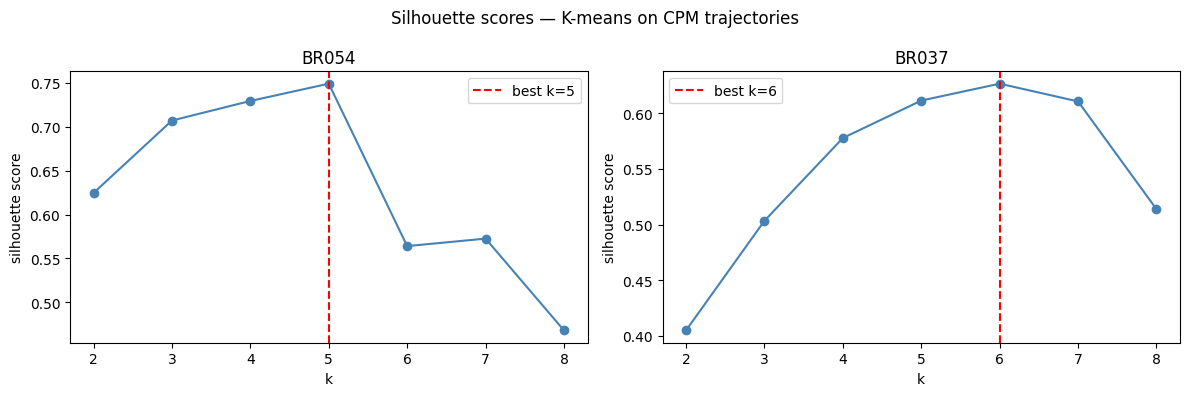

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

cluster_results = {}

fig_sil, axes_sil = plt.subplots(1, len(test_pids), figsize=(12, 4))
fig_sil.suptitle("Silhouette scores — K-means on CPM trajectories")

for ax, pid in zip(axes_sil, test_pids):

    # --- 1. filter to significant clonotypes for this patient ---
    sig_clonos = results[
        (results['patient'] == pid) & (results['q_value'] < 0.05)
    ]['clono'].values

    pdf = patient_df_sub[
        (patient_df_sub['patient'] == pid) &
        (patient_df_sub['clono'].isin(sig_clonos))
    ].copy()

    # --- 2. compute CPM using existing lib column ---
    pdf['cpm'] = pdf['count'] / pdf['lib'] * 1e6

    # --- 3. pivot to clonotype x timepoint matrix ---
     # --- 3. pivot to clonotype x timepoint matrix ---
    pivot = pdf.pivot_table(index='clono', columns='day', values='cpm')
    
    # keep clonotypes detected at >= min_obs timepoints (fill missing with 0)
    min_timepoints = 3
    pivot = pivot[pivot.notna().sum(axis=1) >= min_timepoints]
    pivot = pivot.fillna(0)  # fill undetected timepoints with 0 CPM

    print(f"{pid}: {len(pivot)} clonotypes with >={min_timepoints} timepoints for clustering")

    # --- 4. scale rows so shape dominates, not magnitude ---
    X = StandardScaler().fit_transform(pivot.T).T

    # --- 5. silhouette sweep k=2..8 ---
    k_range = range(2, 9)
    sil_scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)

    best_k = list(k_range)[np.argmax(sil_scores)]
    print(f"  Best k={best_k} (silhouette={max(sil_scores):.3f})")

    ax.plot(list(k_range), sil_scores, 'o-', color='steelblue')
    ax.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
    ax.set_xlabel('k')
    ax.set_ylabel('silhouette score')
    ax.set_title(pid)
    ax.legend()

    # --- 6. fit final clustering with best_k ---
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_final = km_final.fit_predict(X)
    pivot['cluster'] = labels_final

    cluster_results[pid] = pivot

plt.tight_layout()
plt.show()

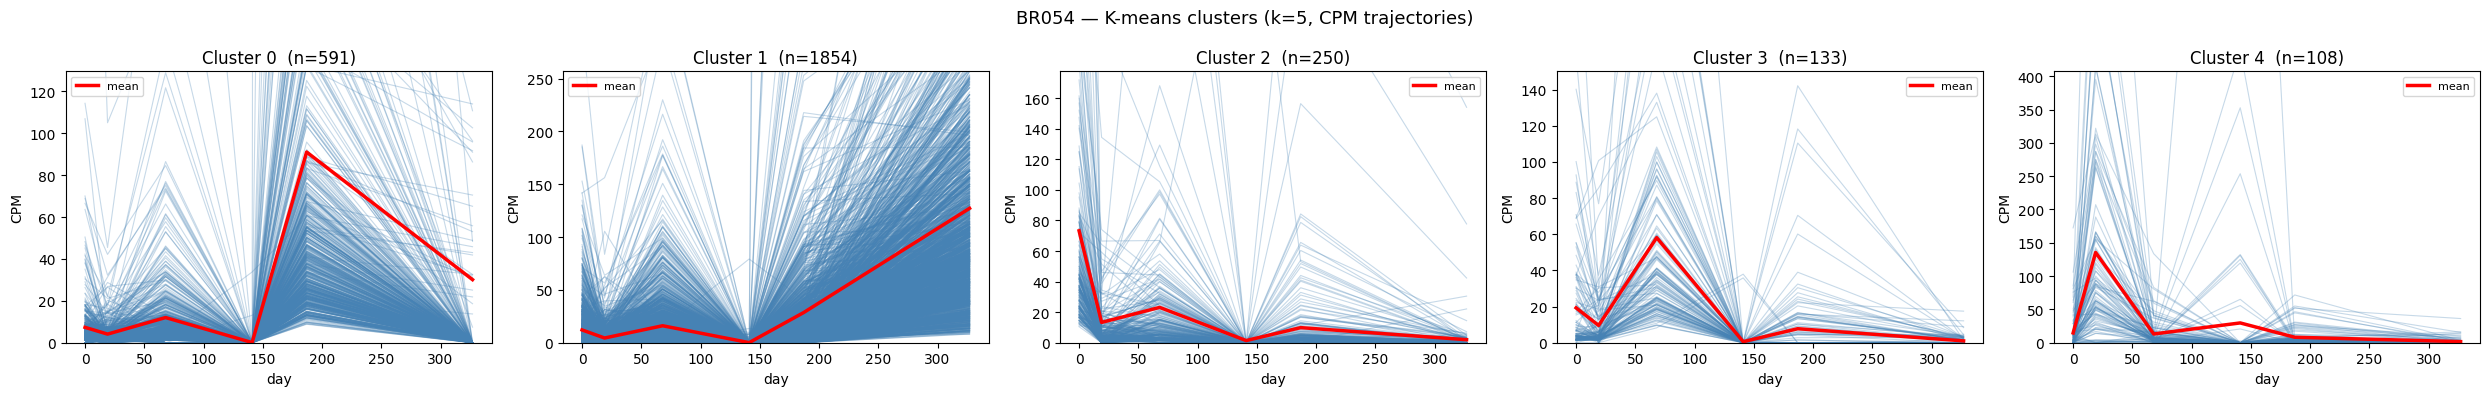

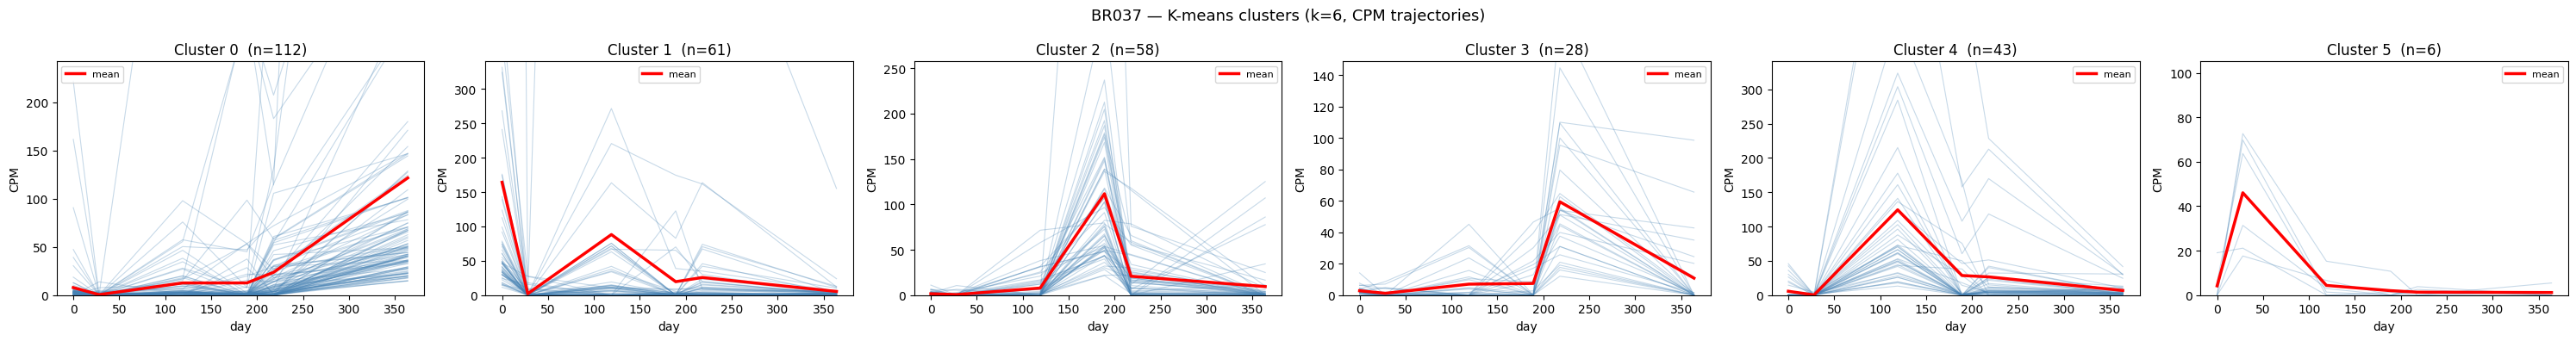

In [25]:
for pid in test_pids:
    if pid not in cluster_results:
        continue

    pivot = cluster_results[pid]
    best_k = pivot['cluster'].nunique()
    days = [c for c in pivot.columns if c not in ('cluster', 'direction')]

    fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 4), sharey=False)
    fig.suptitle(f"{pid} — K-means clusters (k={best_k}, CPM trajectories)", fontsize=13)

    if best_k == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        clust = pivot[pivot['cluster'] == k][days]
        n = len(clust)

        # clip y to 95th percentile per cluster to suppress outliers
        y_max = clust.values.flatten()
        y_max = np.percentile(y_max[y_max > 0], 95) * 1.5

        for _, row in clust.iterrows():
            ax.plot(days, row.values, color='steelblue', alpha=0.3, linewidth=0.8)

        mean_traj = clust.mean()
        ax.plot(days, mean_traj.values, color='red', linewidth=2.5, label='mean')

        ax.set_ylim(0, y_max)
        ax.set_title(f"Cluster {k}  (n={n})")
        ax.set_xlabel('day')
        ax.set_ylabel('CPM')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("cluster_test_"+str(pid)+".png")
    plt.show()

## Fitting the NB with normalized data
In the test above, we have fitted the NB with raw counts. In this following test, we will fit normalized data and compare the results. We use TMM to obtain scaling factor which can be the functions take as input to adjust library sizes.

In [26]:
healthy_df_TMM = tmm_normalize(healthy_df)

In [27]:
healthy_df_TMM

,patient,day,clono,count,tmm_factor
0,HD106_SEQTR,0,clono_1,226089,0.902231
1,HD106_SEQTR,0,clono_10,37237,0.902231
2,HD106_SEQTR,0,clono_100,5035,0.902231
3,HD106_SEQTR,0,clono_1000,830,0.902231
4,HD106_SEQTR,0,clono_10000,247,0.902231
...,...,...,...,...,...
2969987,HDBR06_SEQTR_ReSeq,105,clono_99934,34,1.000000
2969988,HDBR06_SEQTR_ReSeq,105,clono_99946,53,1.000000
2969989,HDBR06_SEQTR_ReSeq,105,clono_99969,206,1.000000
2969990,HDBR06_SEQTR_ReSeq,105,clono_99982,22,1.000000


In [28]:
nb_joint_TMM = fit_nb_dispersion_mle(healthy_df_TMM, norm_factors="tmm_factor")

In [29]:
nb_joint_TMM

{'phi': 4.081837467184515,
 'x_all': array([2.26089e+05, 2.38914e+05, 1.28798e+05, ..., 2.20000e+01,
        1.20000e+01, 3.40000e+01]),
 'mu_all': array([2.01840077e+05, 2.36295005e+05, 1.31609406e+05, ...,
        1.64459550e+01, 2.37495903e+01, 2.22504097e+01])}

Lets check which clonotypes get selected

In [30]:
from tcr_pipeline.nb_glm import _attach_lib
##Working on the _sub data frame which only includes the two test patients we selected for the examples
patient_df_tmm = tmm_normalize(patient_df_sub)
patient_df_tmm = _attach_lib(patient_df_tmm, count_col='count', norm_factors='tmm_factor')

In [31]:
results_tmm = nb_glm_trajectory_test(patient_df_tmm, dispersion=nb_joint_TMM["phi"], count_col='count', min_obs=3)
results_tmm['q_value'] = results_tmm.groupby('patient')['p_value'].transform(bh_correct)

### Lest compare the results vs the non-tmm fit

In [32]:
print("Test summary")
for pid in test_pids:
    sub = results[results['patient'] == pid]
    sig = sub[sub['q_value'] < 0.05]

    print(f"\nPatient: {pid}")
    print(f"  Total clonotypes tested:    {len(sub)}")
    print(f"  Converged:                  {sub['converged'].sum()} ({100*sub['converged'].mean():.1f}%)")
    print(f"  Significant (FDR 5%):       {len(sig)}")
    print(f"  Significant (FDR 10%):      {(sub['q_value'] < 0.10).sum()}")
    print(f"  Expansions  (FDR 5%):       {(sig['direction'] == 'expansion').sum()}")
    print(f"  Contractions (FDR 5%):      {(sig['direction'] == 'contraction').sum()}")
    print(f"\n  p-value distribution:")
    print(f"    < 0.001 : {(sub['p_value'] < 0.001).sum()}")
    print(f"    < 0.01  : {(sub['p_value'] < 0.01).sum()}")
    print(f"    < 0.05  : {(sub['p_value'] < 0.05).sum()}")
    print(f"\n  Top 5 expansions:")
    top_exp = sig[sig['direction'] == 'expansion'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_exp.to_string(index=False))
    print(f"\n  Top 5 contractions:")
    top_con = sig[sig['direction'] == 'contraction'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_con.to_string(index=False))
    print("-" * 60)

Test summary

Patient: BR054
  Total clonotypes tested:    21116
  Converged:                  21116 (100.0%)
  Significant (FDR 5%):       2936
  Significant (FDR 10%):      3854
  Expansions  (FDR 5%):       2543
  Contractions (FDR 5%):      393

  p-value distribution:
    < 0.001 : 1795
    < 0.01  : 3240
    < 0.05  : 5379

  Top 5 expansions:
      clono     beta      p_value      q_value  n_obs
clono_14649 0.028746 3.815289e-22 8.056365e-18      5
 clono_6043 0.025150 3.500776e-19 3.696119e-15      5
clono_74308 0.014313 1.158646e-14 8.155323e-11      5
clono_89033 0.014238 2.463686e-14 1.300580e-10      5
clono_68864 0.013886 8.984806e-14 3.794463e-10      4

  Top 5 contractions:
      clono      beta      p_value      q_value  n_obs
   clono_22 -0.083959 4.628157e-11 3.369937e-08      3
clono_99213 -0.026236 3.022176e-08 4.462676e-06      3
clono_99254 -0.026671 3.616648e-08 5.160077e-06      3
 clono_2821 -0.012482 4.367234e-08 5.873791e-06      5
clono_21476 -0.012043 1.50

In [33]:
print("Test summary TMM")
for pid in test_pids:
    sub = results_tmm[results_tmm['patient'] == pid]
    sig = sub[sub['q_value'] < 0.05]

    print(f"\nPatient: {pid}")
    print(f"  Total clonotypes tested:    {len(sub)}")
    print(f"  Converged:                  {sub['converged'].sum()} ({100*sub['converged'].mean():.1f}%)")
    print(f"  Significant (FDR 5%):       {len(sig)}")
    print(f"  Significant (FDR 10%):      {(sub['q_value'] < 0.10).sum()}")
    print(f"  Expansions  (FDR 5%):       {(sig['direction'] == 'expansion').sum()}")
    print(f"  Contractions (FDR 5%):      {(sig['direction'] == 'contraction').sum()}")
    print(f"\n  p-value distribution:")
    print(f"    < 0.001 : {(sub['p_value'] < 0.001).sum()}")
    print(f"    < 0.01  : {(sub['p_value'] < 0.01).sum()}")
    print(f"    < 0.05  : {(sub['p_value'] < 0.05).sum()}")
    print(f"\n  Top 5 expansions:")
    top_exp = sig[sig['direction'] == 'expansion'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_exp.to_string(index=False))
    print(f"\n  Top 5 contractions:")
    top_con = sig[sig['direction'] == 'contraction'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_con.to_string(index=False))
    print("-" * 60)

Test summary TMM

Patient: BR054
  Total clonotypes tested:    21116
  Converged:                  21116 (100.0%)
  Significant (FDR 5%):       1682
  Significant (FDR 10%):      2630
  Expansions  (FDR 5%):       920
  Contractions (FDR 5%):      762

  p-value distribution:
    < 0.001 : 1047
    < 0.01  : 2400
    < 0.05  : 4610

  Top 5 expansions:
      clono     beta      p_value      q_value  n_obs
clono_14649 0.026172 2.483288e-18 5.243711e-14      5
 clono_6043 0.023029 7.957519e-16 8.401548e-12      5
clono_10594 0.021336 4.726119e-12 2.494918e-08      4
clono_74308 0.011348 3.348823e-10 7.071374e-07      5
clono_64511 0.030439 7.759532e-10 1.489548e-06      3

  Top 5 contractions:
      clono      beta      p_value      q_value  n_obs
 clono_2821 -0.017253 1.957919e-12 1.378114e-08      5
clono_21476 -0.016922 6.227525e-12 2.630008e-08      5
   clono_22 -0.084532 2.902551e-11 1.021505e-07      3
clono_20616 -0.015378 9.005702e-11 2.716634e-07      5
clono_99213 -0.031892 1

The TMM adjusted fit is more conserative, selecting fewer significant clonotpyes for the first patient (the same for the second).

BR054: 1682 clonotypes with >=3 timepoints for clustering
  Best k=5 (silhouette=0.638)
BR037: 360 clonotypes with >=3 timepoints for clustering
  Best k=6 (silhouette=0.624)


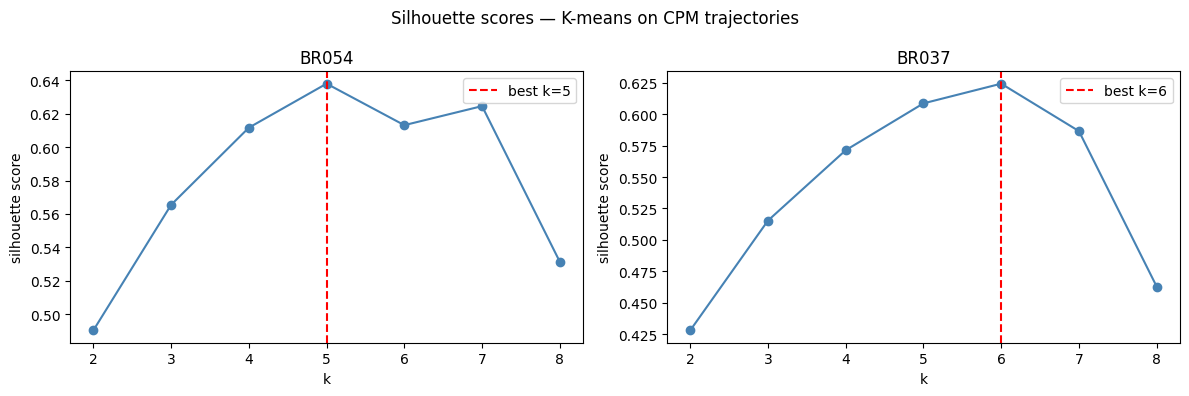

In [34]:
cluster_results = {}

fig_sil, axes_sil = plt.subplots(1, len(test_pids), figsize=(12, 4))
fig_sil.suptitle("Silhouette scores — K-means on CPM trajectories")

for ax, pid in zip(axes_sil, test_pids):

    # --- 1. filter to significant clonotypes for this patient ---
    sig_clonos = results_tmm[
        (results_tmm['patient'] == pid) & (results_tmm['q_value'] < 0.05)
    ]['clono'].values

    pdf = patient_df_tmm[                          
        (patient_df_tmm['patient'] == pid) &        
        (patient_df_tmm['clono'].isin(sig_clonos))  
    ].copy()

    # --- 2. compute CPM using existing lib column ---
    pdf['cpm'] = pdf['count'] / pdf['lib'] * 1e6

    # --- 3. pivot to clonotype x timepoint matrix ---
     # --- 3. pivot to clonotype x timepoint matrix ---
    pivot = pdf.pivot_table(index='clono', columns='day', values='cpm')
    
    # keep clonotypes detected at >= min_obs timepoints (fill missing with 0)
    min_timepoints = 3
    pivot = pivot[pivot.notna().sum(axis=1) >= min_timepoints]
    pivot = pivot.fillna(0)  # fill undetected timepoints with 0 CPM

    print(f"{pid}: {len(pivot)} clonotypes with >={min_timepoints} timepoints for clustering")

    # --- 4. scale rows so shape dominates, not magnitude ---
    X = StandardScaler().fit_transform(pivot.T).T

    # --- 5. silhouette sweep k=2..8 ---
    k_range = range(2, 9)
    sil_scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)

    best_k = list(k_range)[np.argmax(sil_scores)]
    print(f"  Best k={best_k} (silhouette={max(sil_scores):.3f})")

    ax.plot(list(k_range), sil_scores, 'o-', color='steelblue')
    ax.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
    ax.set_xlabel('k')
    ax.set_ylabel('silhouette score')
    ax.set_title(pid)
    ax.legend()

    # --- 6. fit final clustering with best_k ---
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_final = km_final.fit_predict(X)
    pivot['cluster'] = labels_final

    cluster_results[pid] = pivot

plt.tight_layout()
plt.show()

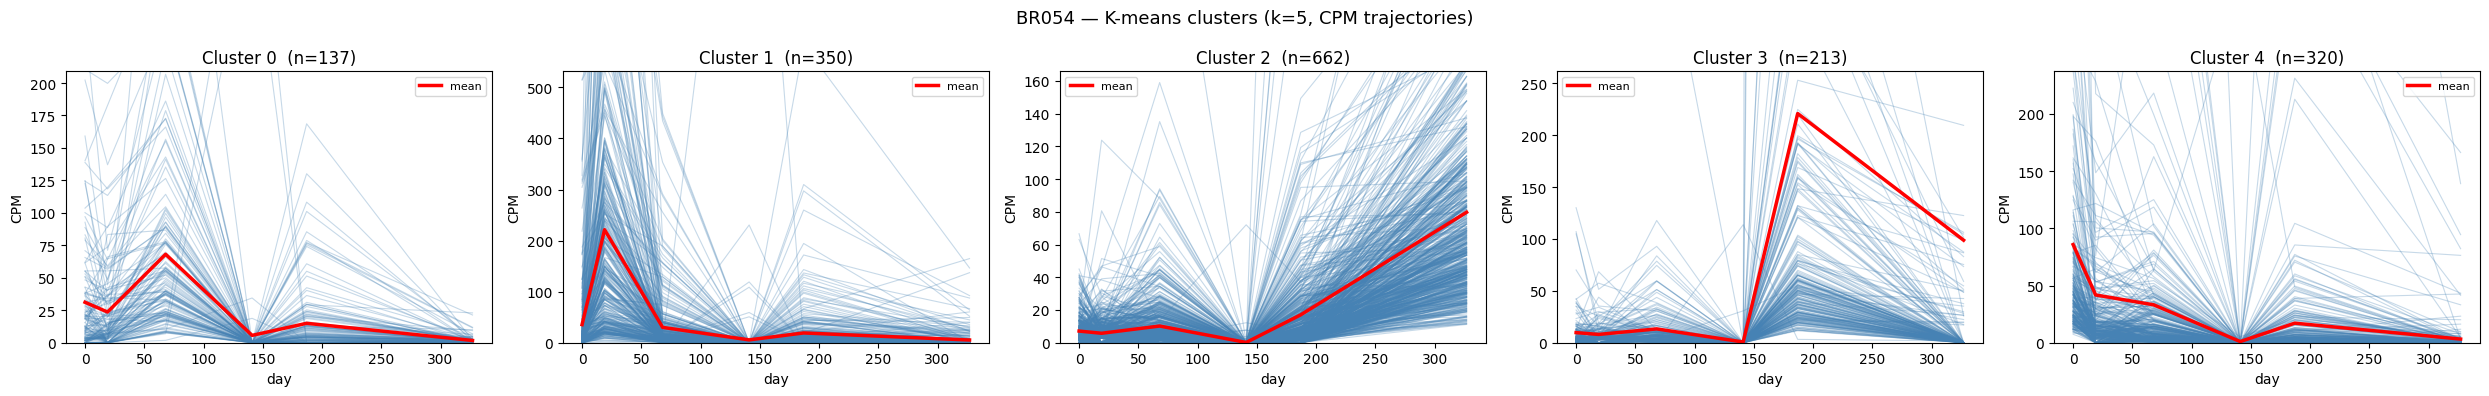

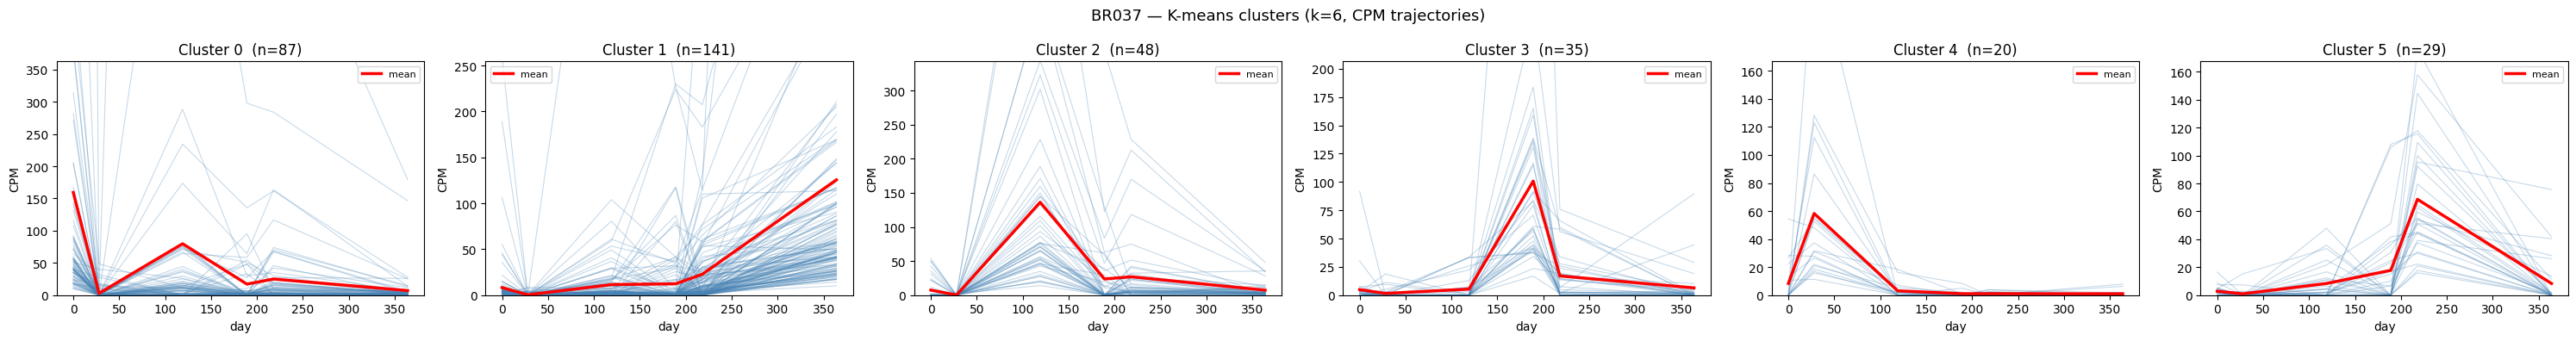

In [35]:
for pid in test_pids:
    if pid not in cluster_results:
        continue

    pivot = cluster_results[pid]
    best_k = pivot['cluster'].nunique()
    days = [c for c in pivot.columns if c not in ('cluster', 'direction')]

    fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 4), sharey=False)
    fig.suptitle(f"{pid} — K-means clusters (k={best_k}, CPM trajectories)", fontsize=13)

    if best_k == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        clust = pivot[pivot['cluster'] == k][days]
        n = len(clust)

        # clip y to 95th percentile per cluster to suppress outliers
        y_max = clust.values.flatten()
        y_max = np.percentile(y_max[y_max > 0], 95) * 1.5

        for _, row in clust.iterrows():
            ax.plot(days, row.values, color='steelblue', alpha=0.3, linewidth=0.8)

        mean_traj = clust.mean()
        ax.plot(days, mean_traj.values, color='red', linewidth=2.5, label='mean')

        ax.set_ylim(0, y_max)
        ax.set_title(f"Cluster {k}  (n={n})")
        ax.set_xlabel('day')
        ax.set_ylabel('CPM')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("cluster_test_tmm_"+str(pid)+".png")
    plt.show()

Comparing these cluster to ones obtained using the raw count data, we can see significant changes for patient "BR054". In principle, the TMM clustering should be more accurate as it corrects for compositional changes across library sizes.

## Exploring frequency dependant noise models.
Until now, we have assimed that there is single dispersion describing noise. However, it is known that dispersion increases with clone frequency. So, we will explore the incorporation of a frequency-aware dispersion. First, we are going to check the dispersion-frequency relationship. Ideally, we would fit a single dispersion pero clonotype, however, due to the sparse number of datapoints that is not possible, istead we will bin the frequency spectrum.

In [36]:
healthy_df_tmm = _attach_lib(healthy_df_TMM, count_col='count', norm_factors='tmm_factor')

In [37]:
p_hats = []
clono_data = []  # (x, mu) pairs per clonotype, aligned with p_hats

min_obs = 2  # matches your current pipeline setting
lo, hi = np.log(1e-3), np.log(1e6)

for (patient, clono), sub in healthy_df_tmm.groupby(['patient', 'clono']):
    if len(sub) < min_obs:
        continue

    p_hat = sub['count'].sum() / sub['lib'].sum()
    if p_hat <= 0 or not np.isfinite(p_hat):
        continue

    mu = p_hat * sub['lib'].values.astype(float)
    x = sub['count'].values.astype(float)
    keep = np.isfinite(mu) & (mu > 1e-8)
    if keep.sum() < min_obs:
        continue

    p_hats.append(p_hat)
    clono_data.append((x[keep], mu[keep]))

p_hats = np.array(p_hats)
print(f"{len(p_hats)} clonotypes")
print(f"p_hat range: {p_hats.min():.2e} to {p_hats.max():.2e}")

271720 clonotypes
p_hat range: 8.27e-07 to 1.69e-01


In [39]:
from scipy.optimize import minimize_scalar
n_bins = 6
lo, hi = np.log(1e-3), np.log(1e6)

log_p = np.log10(p_hats)
bin_edges = np.quantile(log_p, np.linspace(0, 1, n_bins + 1))
bin_edges = np.unique(bin_edges)  # guard against duplicate quantiles
n_bins_actual = len(bin_edges) - 1

bin_idx = np.clip(np.digitize(log_p, bin_edges[1:-1]), 0, n_bins_actual - 1)

bin_labels, bin_phis, bin_ns, bin_at_bound = [], [], [], []

for b in range(n_bins_actual):
    in_bin = bin_idx == b
    n_in_bin = in_bin.sum()
    if n_in_bin < 5:
        bin_labels.append(f"[{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f})")
        bin_phis.append(np.nan)
        bin_ns.append(n_in_bin)
        bin_at_bound.append(False)
        continue

    idx_in_bin = np.where(in_bin)[0]
    x_bin = np.concatenate([clono_data[j][0] for j in idx_in_bin])
    mu_bin = np.concatenate([clono_data[j][1] for j in idx_in_bin])

    res = minimize_scalar(_nb_neg_loglik, args=(x_bin, mu_bin),
                           bounds=(lo, hi), method='bounded')

    at_bound = np.isclose(res.x, lo, atol=1e-3) or np.isclose(res.x, hi, atol=1e-3)

    bin_labels.append(f"[{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f})")
    bin_phis.append(np.exp(res.x))
    bin_ns.append(n_in_bin)
    bin_at_bound.append(at_bound)

for lbl, phi, n, ab in zip(bin_labels, bin_phis, bin_ns, bin_at_bound):
    flag = "  <-- AT BOUND, unreliable" if ab else ""
    print(f"{lbl:>20}: phi = {phi:10.4f}   (n = {n}){flag}")

      [-6.08, -5.63): phi =    34.8896   (n = 45284)
      [-5.63, -5.46): phi =     7.7839   (n = 45281)
      [-5.46, -5.29): phi =     4.7724   (n = 45281)
      [-5.29, -5.11): phi =     3.6073   (n = 45298)
      [-5.11, -4.85): phi =     2.9531   (n = 45285)
      [-4.85, -0.77): phi =     2.8703   (n = 45291)


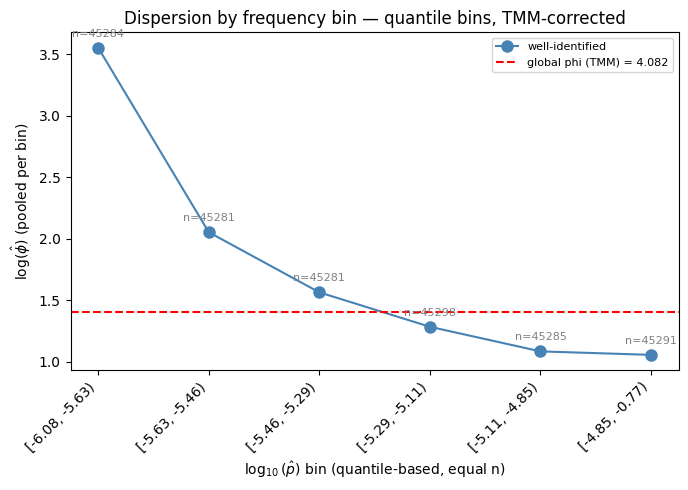

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
bin_centers = range(len(bin_labels))

bin_phis_arr = np.array(bin_phis, dtype=float)
bin_at_bound_arr = np.array(bin_at_bound)

good = ~bin_at_bound_arr & np.isfinite(bin_phis_arr)
bad = bin_at_bound_arr & np.isfinite(bin_phis_arr)

ax.plot(np.array(list(bin_centers))[good], np.log(bin_phis_arr[good]),
        'o-', color='steelblue', markersize=8, label='well-identified')
if bad.any():
    ax.plot(np.array(list(bin_centers))[bad], np.log(bin_phis_arr[bad]),
            'o', color='lightgray', markersize=8, label='at bound (unreliable)')

for i, n in enumerate(bin_ns):
    if np.isfinite(bin_phis_arr[i]):
        ax.annotate(f'n={n}', (i, np.log(bin_phis_arr[i])), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=8, color='gray')

ax.axhline(np.log(4.081837467184515), color='red', linestyle='--',
           label='global phi (TMM) = 4.082')
ax.set_xticks(list(bin_centers))
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.set_xlabel(r'$\log_{10}(\hat{p})$ bin (quantile-based, equal n)')
ax.set_ylabel(r'$\log(\hat{\phi})$ (pooled per bin)')
ax.set_title('Dispersion by frequency bin — quantile bins, TMM-corrected')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("dispersion_vs_frequency_binned.png", dpi=150)
plt.show()

As we can see, there is a clear downwards trend. Low frequency clonoypes are closer to Poisson (in Poisson phi->inf) whereas more abundant clonotpyes seems to have a better defined dispersion.

### Frequency-aware fitting
We will perform frequency-aware fitting using fit_dispersion_trended_mle

In [41]:
from tcr_pipeline.nb_glm import fit_nb_dispersion_trended, nb_glm_trajectory_test

trend_model_tmm = fit_nb_dispersion_trended(healthy_df_TMM, count_col='count', norm_factors='tmm_factor', n_bins=6)
print(trend_model_tmm['phi_per_bin'])
print(trend_model_tmm['bin_n'])
print(trend_model_tmm['bin_at_bound'])

[34.889552067856236, 7.783947440361677, 4.772446316586409, 3.607333049196441, 2.953068187027328, 2.8702870488873593]
[45284, 45281, 45281, 45298, 45285, 45291]
[False, False, False, False, False, False]


In [42]:
results_tmm_trended = nb_glm_trajectory_test(patient_df_tmm, dispersion=trend_model_tmm, count_col='count', min_obs=3)
results_tmm_trended['q_value'] = results_tmm_trended.groupby('patient')['p_value'].transform(bh_correct)

In [43]:
print("Test summary TMM trended dispersion")
for pid in test_pids:
    sub = results_tmm_trended[results_tmm_trended['patient'] == pid]
    sig = sub[sub['q_value'] < 0.05]

    print(f"\nPatient: {pid}")
    print(f"  Total clonotypes tested:    {len(sub)}")
    print(f"  Converged:                  {sub['converged'].sum()} ({100*sub['converged'].mean():.1f}%)")
    print(f"  Significant (FDR 5%):       {len(sig)}")
    print(f"  Significant (FDR 10%):      {(sub['q_value'] < 0.10).sum()}")
    print(f"  Expansions  (FDR 5%):       {(sig['direction'] == 'expansion').sum()}")
    print(f"  Contractions (FDR 5%):      {(sig['direction'] == 'contraction').sum()}")
    print(f"\n  p-value distribution:")
    print(f"    < 0.001 : {(sub['p_value'] < 0.001).sum()}")
    print(f"    < 0.01  : {(sub['p_value'] < 0.01).sum()}")
    print(f"    < 0.05  : {(sub['p_value'] < 0.05).sum()}")
    print(f"\n  Top 5 expansions:")
    top_exp = sig[sig['direction'] == 'expansion'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_exp.to_string(index=False))
    print(f"\n  Top 5 contractions:")
    top_con = sig[sig['direction'] == 'contraction'].nsmallest(5, 'q_value')[
        ['clono', 'beta', 'p_value', 'q_value', 'n_obs']
    ]
    print(top_con.to_string(index=False))
    print("-" * 60)

Test summary TMM trended dispersion

Patient: BR054
  Total clonotypes tested:    21116
  Converged:                  21116 (100.0%)
  Significant (FDR 5%):       741
  Significant (FDR 10%):      1479
  Expansions  (FDR 5%):       389
  Contractions (FDR 5%):      352

  p-value distribution:
    < 0.001 : 558
    < 0.01  : 1750
    < 0.05  : 4030

  Top 5 expansions:
      clono     beta      p_value      q_value  n_obs
clono_14649 0.026181 2.314621e-13 4.887553e-09      5
 clono_6043 0.023034 1.387576e-11 1.465003e-07      5
clono_10594 0.021285 6.311143e-09 3.093378e-05      4
clono_74308 0.011320 1.058048e-07 2.234174e-04      5
clono_64511 0.030441 2.150539e-07 4.128252e-04      3

  Top 5 contractions:
      clono      beta      p_value  q_value  n_obs
 clono_2821 -0.017231 3.359650e-09 0.000024      5
clono_21476 -0.016897 7.324725e-09 0.000031      5
   clono_22 -0.084170 2.197850e-08 0.000077      3
clono_20616 -0.015360 5.068845e-08 0.000153      5
clono_99213 -0.031791 6.77

In [46]:
lost_sig = comparison[(comparison['q_value_scalar'] < 0.05) & (comparison['q_value_trended'] >= 0.05)]
gained_sig = comparison[(comparison['q_value_scalar'] >= 0.05) & (comparison['q_value_trended'] < 0.05)]

print(f"Lost significance: {len(lost_sig)}, mean phi_used: {lost_sig['phi_used_trended'].mean():.2f}")
print(f"Gained significance: {len(gained_sig)}, mean phi_used: {gained_sig['phi_used_trended'].mean():.2f}")

Lost significance: 1243, mean phi_used: 2.94
Gained significance: 74, mean phi_used: 24.63


From the change in significance, we can see that we lost signicance (less clontypes were flagged as expanding/contracting) for the high frequency models with the new more conservative noise estimate, as expected.
For the low frequency clonotypes, the oposite happends. Using hihher phi (less overdispersion, closer to Poisson) we are able to identify more clonotypes, meaning that using the mean_phi approach vas overestimating sampling noise for rare clonotypes and masking actual expansion/contractions